Linear Kernel Accuracy: 1.0
Confusion Matrix (Linear):
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


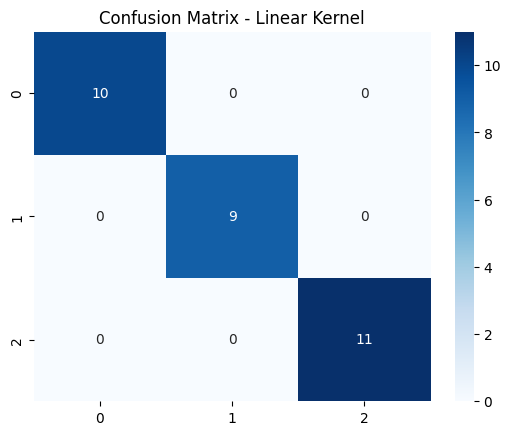

RBF Kernel Accuracy: 1.0
Confusion Matrix (RBF):
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


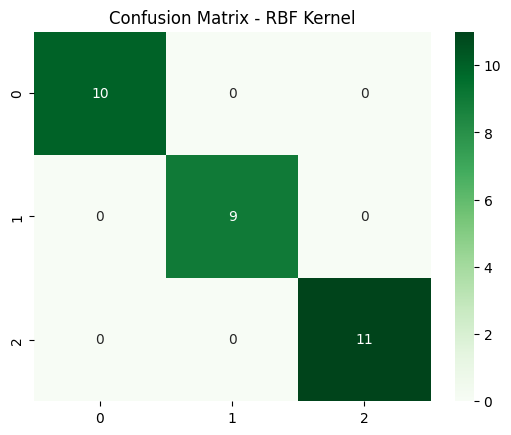

In [2]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
data = pd.read_excel("/content/iris (1).xlsx")

# Features and target
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

# Train test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# ---------------- Linear Kernel ----------------
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train, y_train)

y_pred_linear = svm_linear.predict(X_test)

print("Linear Kernel Accuracy:", accuracy_score(y_test, y_pred_linear))

cm_linear = confusion_matrix(y_test, y_pred_linear)
print("Confusion Matrix (Linear):\n", cm_linear)

sns.heatmap(cm_linear, annot=True, cmap="Blues")
plt.title("Confusion Matrix - Linear Kernel")
plt.show()


# ---------------- RBF Kernel ----------------
svm_rbf = SVC(kernel='rbf')
svm_rbf.fit(X_train, y_train)

y_pred_rbf = svm_rbf.predict(X_test)

print("RBF Kernel Accuracy:", accuracy_score(y_test, y_pred_rbf))

cm_rbf = confusion_matrix(y_test, y_pred_rbf)
print("Confusion Matrix (RBF):\n", cm_rbf)

sns.heatmap(cm_rbf, annot=True, cmap="Greens")
plt.title("Confusion Matrix - RBF Kernel")
plt.show()

Accuracy: 0.8545
Confusion Matrix:
 [[140   1   0   0   0   0   2   0   0   2   0   0   0   0   0   0   0   1
    1   0   0   1   0   0   1   0]
 [  1 133   0   3   0   0   0   5   0   0   1   0   0   1   0   1   0   6
    1   0   0   1   0   0   0   0]
 [  0   0 117   0   1   0   4   2   0   0   6   1   0   0   3   0   0   0
    1   0   2   0   0   0   0   0]
 [  0   6   0 141   0   0   0   2   0   1   2   0   0   1   1   0   0   0
    0   2   0   0   0   0   0   0]
 [  0   1   2   0 127   0   4   0   0   0   1   1   0   0   0   0   1   1
    2   1   0   0   0   0   0   0]
 [  0   0   0   0   3 127   0   1   2   1   0   0   0   0   0   1   0   0
    2   3   0   0   0   0   0   0]
 [  0   1   8   2   0   0 129   2   0   1   3   0   0   0   0   0   7   1
    2   0   0   2   2   0   0   0]
 [  1   4   1  10   1   2   0  85   0   3   6   0   0   2  10   1   2  12
    0   0   2   0   0   1   1   0]
 [  0   0   0   3   0   2   0   0 127   6   0   2   0   0   0   0   1   0
    1   0   0   0 

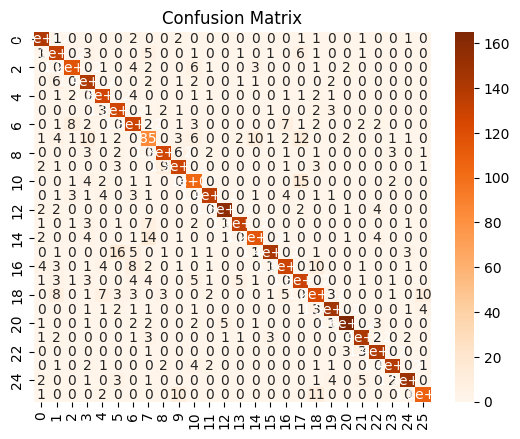

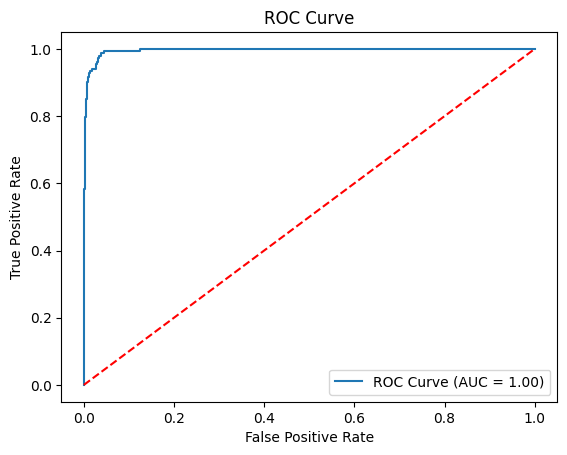

AUC Score: 0.9955181101987628


In [4]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
data = pd.read_excel("/content/letter-recognition.xlsx")

# Features and target
# Assuming the first column is the target letter and the rest are features
X = data.iloc[:, 1:] # Features are all columns except the first one
y = data.iloc[:, 0]  # Target is the first column ('letter')

# Encode categorical target
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y) # Encode the target 'letter' column

# Train test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Train SVM model
svm_model = SVC(kernel='linear', probability=True)
svm_model.fit(X_train, y_train)

# Prediction
y_pred = svm_model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

sns.heatmap(cm, annot=True, cmap="Oranges")
plt.title("Confusion Matrix")
plt.show()


# ROC Curve
# Note: ROC curves are typically used for binary classification. For multi-class,
# you might need to plot one-vs-rest or average ROC curves.
# The current setup will attempt a binary ROC on multi-class data if `pos_label` is used,
# or will raise an error if `predict_proba` returns >2 columns and `pos_label` is missing.
# For simplicity, we'll keep the current approach assuming a relevant class for pos_label=1.
# However, it's more appropriate to handle multi-class ROC explicitly (e.g., using OvR strategy).

y_prob = svm_model.predict_proba(X_test)

# For binary classification (or one-vs-rest for class 1 in multi-class)
# If you have more than two classes, you'll need a more sophisticated ROC plotting strategy.
fpr, tpr, thresholds = roc_curve(y_test, y_prob[:,1], pos_label=1)

roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label="ROC Curve (AUC = %0.2f)" % roc_auc)
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("AUC Score:", roc_auc)